# Agent S: Nuclei Segmentation

This notebook segments nuclei from the DAPI channel of the MIP images generated in Step 1. It utilizes Cellpose for initial segmentation and optionally SAM for refinement.

### Goals:
1. Load MIP images (DAPI channel).
2. Confirm the correct channel is selected for DAPI.
3. Perform segmentation with user-tuned parameters (Diameter, Flow Threshold).
4. Generate unique Nucleus IDs.
5. Export masks and metadata (Pickle) for spot assignment.

In [1]:
import os
import pickle
import numpy as np
import tifffile
import matplotlib.pyplot as plt
from cellpose import models
from skimage import measure

# Default rendering settings
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 10)

## 1. Parameters

Adjust the following parameters for your dataset. The DAPI channel is usually the last channel in our compiled MIPs.

In [2]:
mip_dir = "/Volumes/guttman/primarydata/imaging/20251223-ONI-gmgao-ViewRNAXistInExTsix-WT_dTsixdSPEN_dSPENDox24h/WT/results/01_MIPs"
output_dir = "/Volumes/guttman/primarydata/imaging/20251223-ONI-gmgao-ViewRNAXistInExTsix-WT_dTsixdSPEN_dSPENDox24h/WT/results/02_Segmentation"

# DAPI channel index (0-indexed).
# e.g., if channels are [RNA1, RNA2, DAPI], DAPI is index 2 or -1.
dapi_channel_idx = -1

# Cellpose Parameters
nucleus_diameter = 80.0
flow_threshold = 0.4
cellprob_threshold = 0.0

os.makedirs(output_dir, exist_ok=True)

## 2. Channel Confirmation

Let's visualize the selected DAPI channel for the first image to confirm we grabbed the right one.

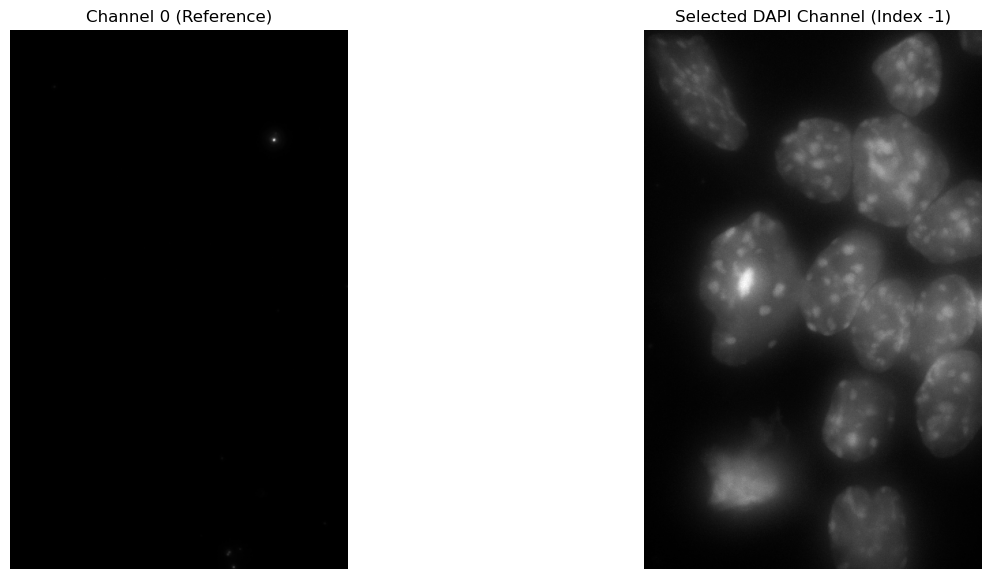

In [3]:
mip_files_list = [f for f in os.listdir(mip_dir) if f.endswith(".tif")]
if mip_files_list:
    first_img_path = os.path.join(mip_dir, mip_files_list[0])
    test_img = tifffile.imread(first_img_path)

    fig, axes = plt.subplots(1, 2, figsize=(15, 7))

    # Show first channel (usually an RNA channel) for contrast
    axes[0].imshow(test_img[0], cmap='gray')
    axes[0].set_title("Channel 0 (Reference)")
    axes[0].axis('off')

    # Show selected DAPI channel
    dapi_test = test_img[dapi_channel_idx] if test_img.ndim == 3 else test_img
    axes[1].imshow(dapi_test, cmap='gray')
    axes[1].set_title(f"Selected DAPI Channel (Index {dapi_channel_idx})")
    axes[1].axis('off')

    plt.show()
else:
    print("No .tif files found in mip_dir!")


## 3. Load Model

Initializing the specified Cellpose model.

In [4]:
model = models.CellposeModel(
    gpu=True,
    # model_type=model_type,
)

## 4. Segment and Save

Processing all MIPs in the directory.

In [5]:
from rich.progress import Progress

mip_files = [f for f in os.listdir(mip_dir) if f.endswith(".tif")]
print(f"Found {len(mip_files)} MIP files.")

with Progress() as progress:
    task = progress.add_task("[cyan]Segmenting...", total=len(mip_files))
    for filename in mip_files:
        path = os.path.join(mip_dir, filename)
        img = tifffile.imread(path)

        # Extract DAPI channel
        dapi = img[dapi_channel_idx] if img.ndim == 3 else img

        # Segment
        masks, flows, styles = model.eval(
            dapi,
            diameter=nucleus_diameter,
            # channels=[0, 0],
            flow_threshold=flow_threshold,
            cellprob_threshold=cellprob_threshold,
        )

        # Save Mask TIFF
        mask_path = os.path.join(output_dir, filename.replace(".tif", "_masks.tif"))
        tifffile.imwrite(mask_path, masks.astype(np.uint16))

        # Extract Nucleus Data (compatible with GGscripts)
        props = measure.regionprops(masks)
        nucleus_data = []
        for p in props:
            nucleus_data.append(
                {"id": p.label, "centroid": p.centroid, "bbox": p.bbox, "area": p.area}
            )

        # Save Metadata Pickle
        pkl_data = {
            "filename": filename,
            "masks_nuclei": masks,
            "nucleus_data": nucleus_data,
            "params": {"diameter": nucleus_diameter, "flow_threshold": flow_threshold},
        }

        pkl_path = os.path.join(
            output_dir, filename.replace(".tif", "_segmentation.pkl")
        )
        with open(pkl_path, "wb") as f:
            pickle.dump(pkl_data, f)

        progress.update(task, advance=1, description=f"Segmenting...")
print("Segmentation completed.")

Output()

Found 28 MIP files.


Segmentation completed.


## 5. Visualization

Overlay masks on DAPI for the last processed image.

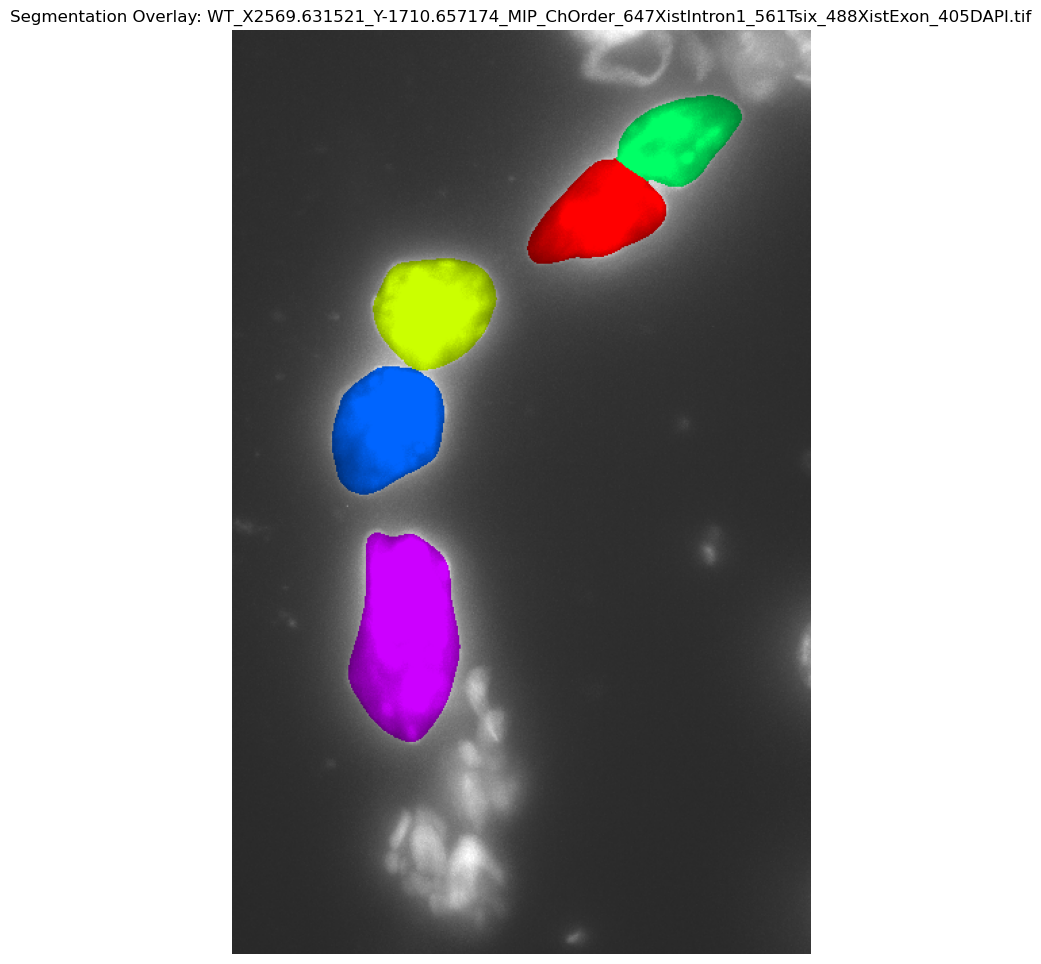

In [ ]:
if 'masks' in locals():
    from cellpose import plot
    import numpy as np

    # Normalize DAPI to [0, 1] for visualization as it is likely 16-bit
    vmax = np.percentile(dapi, 99.9)
    dapi_norm = np.clip(dapi, 0, vmax) / vmax

    fig = plt.figure(figsize=(12,12))
    outline = plot.mask_overlay(dapi_norm, masks)
    plt.imshow(outline)
    plt.title(f"Segmentation Overlay: {filename}")
    plt.axis('off')
    plt.show()